In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os

PROJECT_DIR = "/content/drive/MyDrive/bottle_yolo_training"
os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)

print("Aktualny katalog:", os.getcwd())

Aktualny katalog: /content/drive/MyDrive/bottle_yolo_training


In [7]:
!pip install -q ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 143.9 MB/s eta 0:00:00


In [8]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.7/112.6 GB disk)


In [9]:
from google.colab import userdata

ROBOFLOW_API_KEY = "---------"

In [10]:
from roboflow import Roboflow

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("butelki").project("defekty_butelek2")
version = project.version(1)
dataset = version.download("yolov11")

print("Dataset location:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...
Dataset location: /content/drive/MyDrive/bottle_yolo_training/defekty_butelek2-1


In [11]:
import os

DATASET_PATH = dataset.location
print("DATASET_PATH:", DATASET_PATH)
print(os.listdir(DATASET_PATH))

DATASET_PATH: /content/drive/MyDrive/bottle_yolo_training/defekty_butelek2-1
['README.dataset.txt', 'README.roboflow.txt', 'data.yaml', 'test', 'train', 'valid']


In [12]:
data_yaml_path = os.path.join(DATASET_PATH, "data.yaml")

with open(data_yaml_path, "r") as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 3
names: ['butelka', 'etykieta', 'korek']

roboflow:
  workspace: butelki
  project: defekty_butelek2
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/butelki/defekty_butelek2/dataset/1


In [16]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")



In [17]:
RUN_PATH = os.path.join(PROJECT_DIR, "runs", "bottle_yolo11s_v1")
print(RUN_PATH)
print(os.listdir(RUN_PATH))

/content/drive/MyDrive/bottle_yolo_training/runs/bottle_yolo11s_v1
['weights', 'args.yaml', 'labels.jpg', 'train_batch0.jpg', 'train_batch1.jpg', 'train_batch2.jpg', 'train_batch2310.jpg', 'train_batch2311.jpg', 'train_batch2312.jpg', 'results.csv', 'val_batch0_labels.jpg', 'val_batch0_pred.jpg', 'val_batch1_labels.jpg', 'val_batch1_pred.jpg', 'val_batch2_labels.jpg', 'BoxPR_curve.png', 'val_batch2_pred.jpg', 'BoxF1_curve.png', 'BoxP_curve.png', 'BoxR_curve.png', 'confusion_matrix_normalized.png', 'confusion_matrix.png', 'results.png']


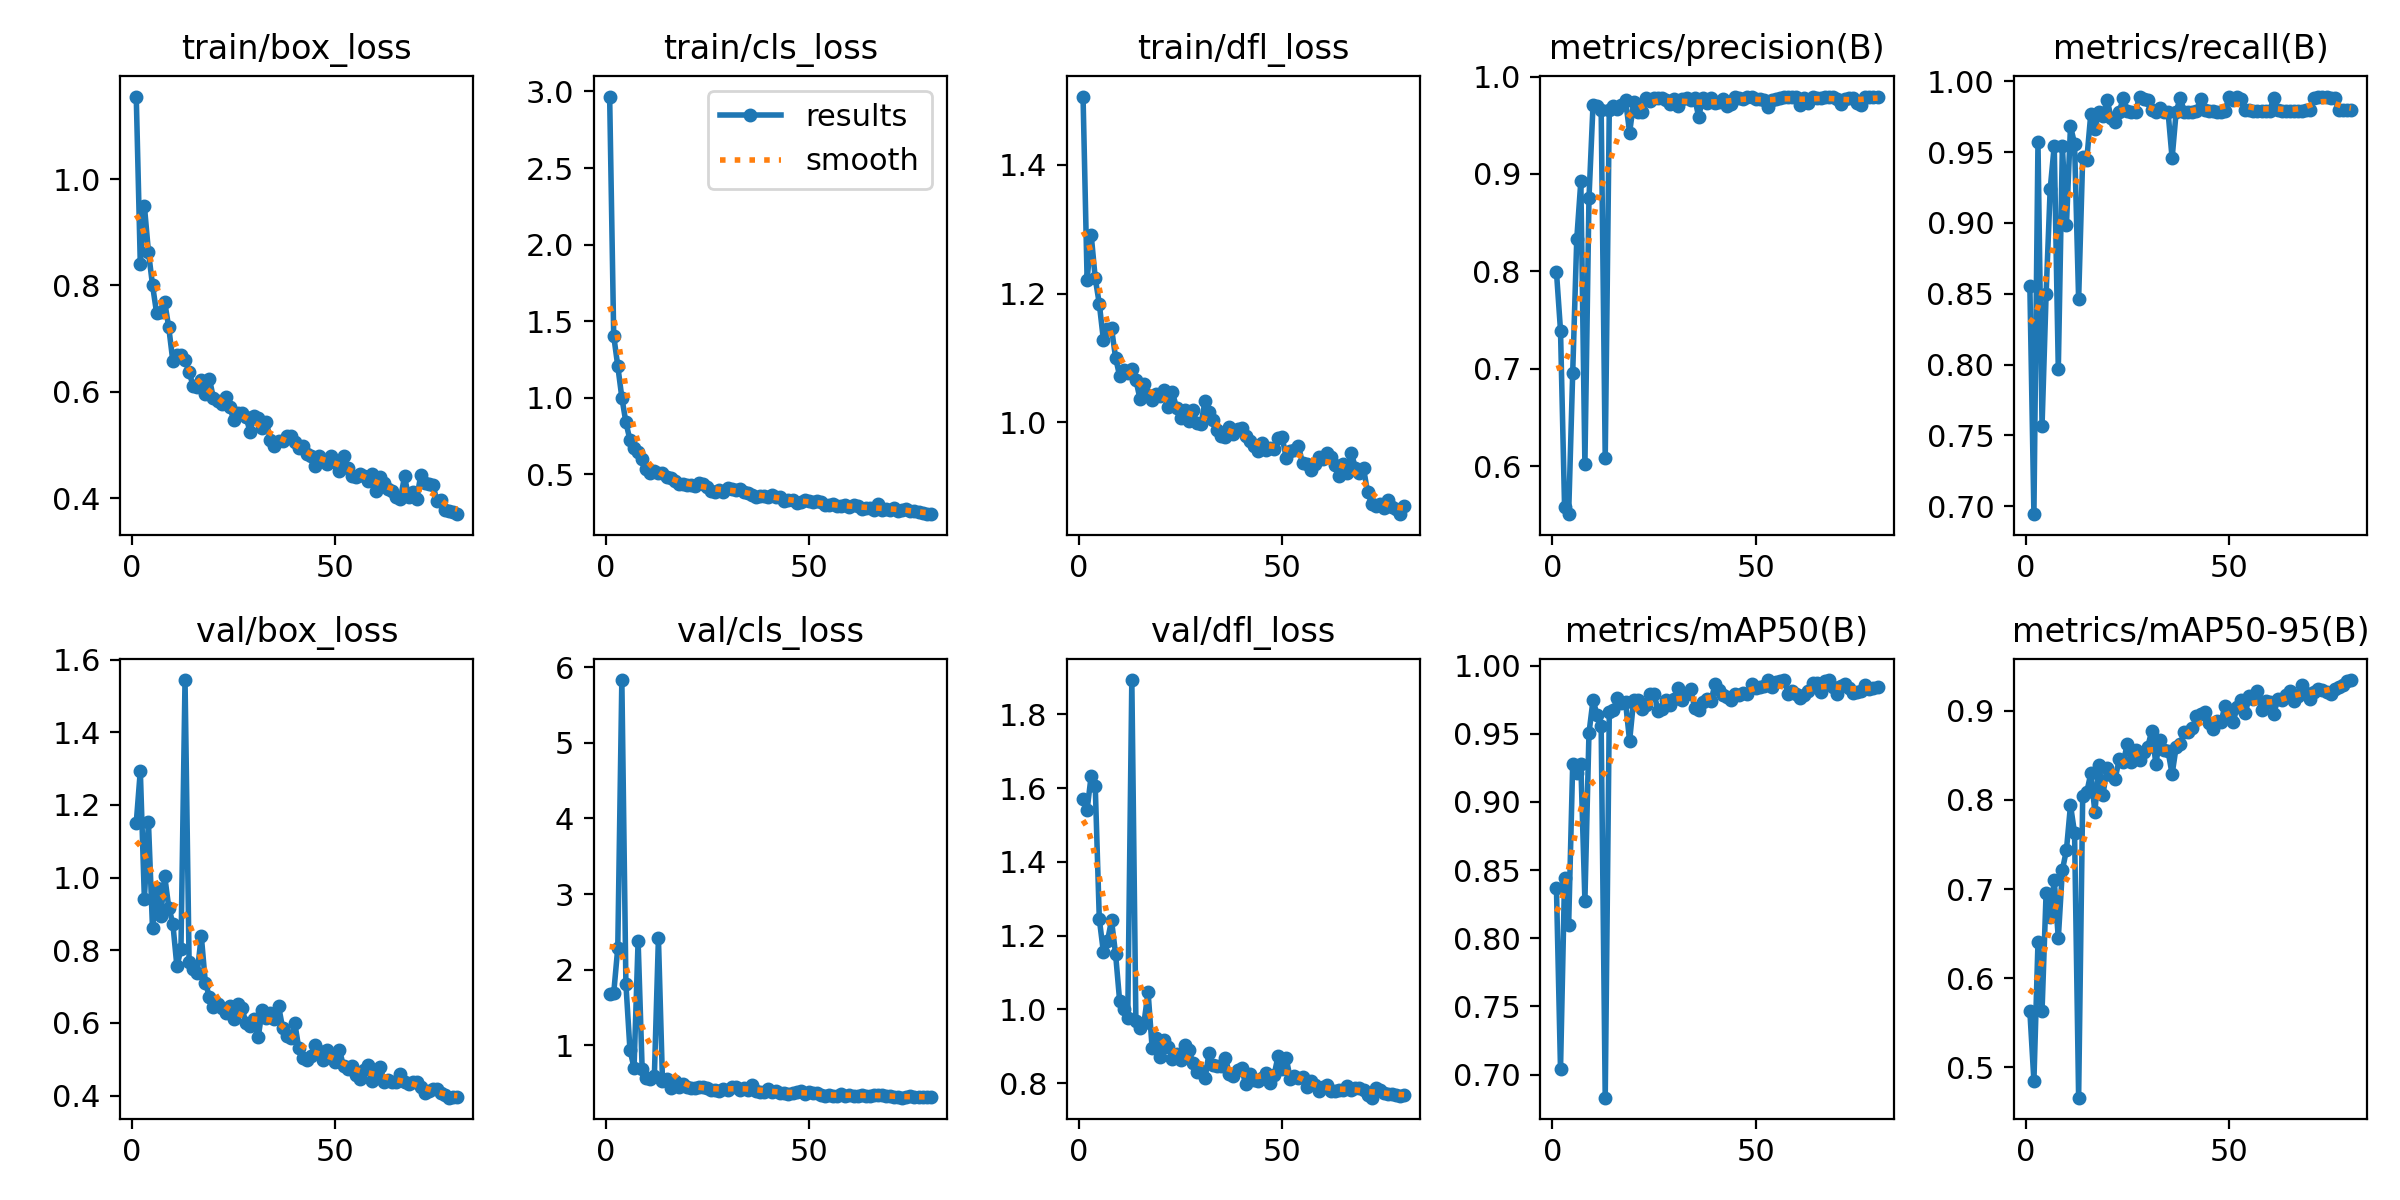

In [18]:
from IPython.display import Image, display
import os

display(Image(filename=os.path.join(RUN_PATH, "results.png"), width=1000))

In [19]:
best_model_path = os.path.join(RUN_PATH, "weights", "best.pt")

best_model = YOLO(best_model_path)
metrics = best_model.val(data=data_yaml_path, split="test")
print(metrics)

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.5 ms, read: 1.2±1.3 MB/s, size: 1140.1 KB)
val: Scanning /content/drive/MyDrive/bottle_yolo_training/defekty_butelek2-1/test/labels.cache... 42 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 42/42 7.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 13.5s/it 40.4s
                   all         42         99      0.997          1      0.995      0.954
               butelka         42         42      0.997          1      0.995      0.981
              etykieta         29         29      0.994          1      0.995       0.98
                 korek         28         28      0.998          1      0.995      0.903
Speed: 7.0ms preprocess, 23.5ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved

In [20]:
import os



TEST_IMAGES_DIR = os.path.join(DATASET_PATH, "test", "images")

results = best_model.predict(
    source=TEST_IMAGES_DIR,
    conf=0.25,
    save=True,
    project=os.path.join(PROJECT_DIR, "predictions"),
    name="bottle_test_preds",
    exist_ok=True
)


image 1/42 /content/drive/MyDrive/bottle_yolo_training/defekty_butelek2-1/test/images/IMG_20240315_134324_saltandpepper_jpg.rf.453d772b0988d905aa50ceb3efe36cf5.jpg: 960x960 1 butelka, 1 etykieta, 1 korek, 29.0ms
image 2/42 /content/drive/MyDrive/bottle_yolo_training/defekty_butelek2-1/test/images/IMG_20240315_134339_contrast_1-5_jpg.rf.40c9cc75ee2b7fed97f5ed4cd955fe1b.jpg: 960x960 1 butelka, 1 etykieta, 1 korek, 29.0ms
image 3/42 /content/drive/MyDrive/bottle_yolo_training/defekty_butelek2-1/test/images/IMG_20240315_134352_gauss_jpg.rf.5f482ecd97b8a67751083cdb7d810dee.jpg: 960x960 1 butelka, 1 etykieta, 1 korek, 29.0ms
image 4/42 /content/drive/MyDrive/bottle_yolo_training/defekty_butelek2-1/test/images/IMG_20240315_134418_saltandpepper_jpg.rf.57fe5ce07c78f874de4ce002dad4dd0f.jpg: 960x960 1 butelka, 1 etykieta, 1 korek, 29.0ms
image 5/42 /content/drive/MyDrive/bottle_yolo_training/defekty_butelek2-1/test/images/IMG_20240315_134445_contrast_1-25_jpg.rf.d9254867ac6eae8638b057731162ba42.

In [22]:
import glob
PRED_DIR = os.path.join(PROJECT_DIR, "predictions", "bottle_test_preds")
print(os.listdir(PRED_DIR)[:10])

['IMG_20240315_134324_saltandpepper_jpg.rf.453d772b0988d905aa50ceb3efe36cf5.jpg', 'IMG_20240315_134339_contrast_1-5_jpg.rf.40c9cc75ee2b7fed97f5ed4cd955fe1b.jpg', 'IMG_20240315_134352_gauss_jpg.rf.5f482ecd97b8a67751083cdb7d810dee.jpg', 'IMG_20240315_134418_saltandpepper_jpg.rf.57fe5ce07c78f874de4ce002dad4dd0f.jpg', 'IMG_20240315_134445_contrast_1-25_jpg.rf.d9254867ac6eae8638b057731162ba42.jpg', 'IMG_20240315_134452_gauss_jpg.rf.15dff2f26dd4737c7925ef4650bc4c57.jpg', 'IMG_20240315_134505_saltandpepper_jpg.rf.08b96fc5fb8c8051dee3699c0d03b70d.jpg', 'IMG_20240315_134653_contrast_0-75_jpg.rf.a6c8ac40a321651eb5b2e43a4a230cad.jpg', 'IMG_20240315_134701_contrast_1-5_jpg.rf.f621952a83ac27f5fb1b48360f159802.jpg', 'IMG_20240315_135835_gauss_jpg.rf.2eeea5127e22d1653238e38473f4dc91.jpg']


In [23]:
best_model.export(format="onnx")

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/drive/MyDrive/bottle_yolo_training/runs/bottle_yolo11s_v1/weights/best.pt' with input shape (1, 3, 960, 960) BCHW and output shape(s) (1, 7, 18900) (18.4 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 182ms
Prepared 4 packages in 4.39s
Installed 4 packages in 249ms
 + colorama==0.4.6
 + onnx==1.20.1
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.89

requirements: AutoUpdate success ✅ 5.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 20...
ONNX: slimming with onnxslim 0.1.89...
ONNX: expor

'/content/drive/MyDrive/bottle_yolo_training/runs/bottle_yolo11s_v1/weights/best.onnx'